In [89]:
!pip install opencv-python


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import cv2
import numpy as np
import pathlib
import matplotlib.pyplot as plt

class ProcesadorPDI:
    def __init__(self, imagen, titulo="Imagen"):
        if isinstance(imagen, (str, pathlib.Path)):
            self.tensor = cv2.imread(str(imagen), cv2.IMREAD_GRAYSCALE)
        else:
            self.tensor = imagen
        self.titulo = titulo

    def to_negative(self):
        return ProcesadorPDI(cv2.bitwise_not(self.tensor), titulo=f"Negativo de {self.titulo}")

    def gamma_transform(self, gamma: float):
        lut = (((np.arange(256) / 255.0) ** gamma) * 255).astype("uint8")
        return ProcesadorPDI(cv2.LUT(self.tensor, lut), titulo=f"Gamma (g={gamma})")

    def log_transform(self):
        c = 255 / np.log1p(255)
        lut = (c * np.log1p(np.arange(256))).astype("uint8")
        return ProcesadorPDI(cv2.LUT(self.tensor, lut), titulo=f"Log de {self.titulo}")

    def binarize(self, umbral: int = 127):
        _, tensor_bin = cv2.threshold(self.tensor, umbral, 255, cv2.THRESH_BINARY)
        return ProcesadorPDI(tensor_bin, titulo=f"Binario (th={umbral})")

    def interpolar(self, r, s):
        lut = np.interp(np.arange(256), r, s).astype("uint8")
        return ProcesadorPDI(cv2.LUT(self.tensor, lut), titulo=f"Interpolado de {self.titulo}")

    def ecualizar(self):
        return ProcesadorPDI(cv2.equalizeHist(self.tensor), titulo=f"Ecualizado de {self.titulo}")

    def show(self):
        cv2.imshow(self.titulo, self.tensor)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
        return self

    def show_jupyter(self, figsize=(10, 4)):
        fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=figsize)
        ax_img.imshow(self.tensor, cmap='gray')
        ax_img.set_title(self.titulo)
        ax_img.axis('off')
        counts, _ = np.histogram(self.tensor.ravel(), bins=256, range=(0, 256))
        ax_hist.bar(range(256), counts, color='gray', width=1)
        ax_hist.fill_between(range(256), counts, color='red', alpha=0.4)
        ax_hist.set_title("Histograma")
        ax_hist.set_xlabel("Intensidad")
        ax_hist.set_ylabel("Frecuencia")
        ax_hist.set_xlim([0, 256])
        ax_hist.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()
        return self

In [91]:
import pathlib

ruta = pathlib.Path.cwd() / "imagenes"

In [92]:
def cargar_imagen(nombre_archivo):
    """Carga una imagen desde el directorio 'imagenes'."""
    return ruta / nombre_archivo

# Ejercicio 1

a) Una radiografía fue tomada para diagnosticar en un paciente problemas en la columna vertebral. Por
un error del operador de la máquina de rayos X, los huesos no aparecen de manera clara. Como el
paciente no puede ser expuesto nuevamente, debido a que ya se ha tomado demasiadas radiografías
para un año, se le pide a usted que procese dicha radiografía para mejorar la definición de los huesos.
Explique cómo seleccionó el procesamiento aplicado.


    

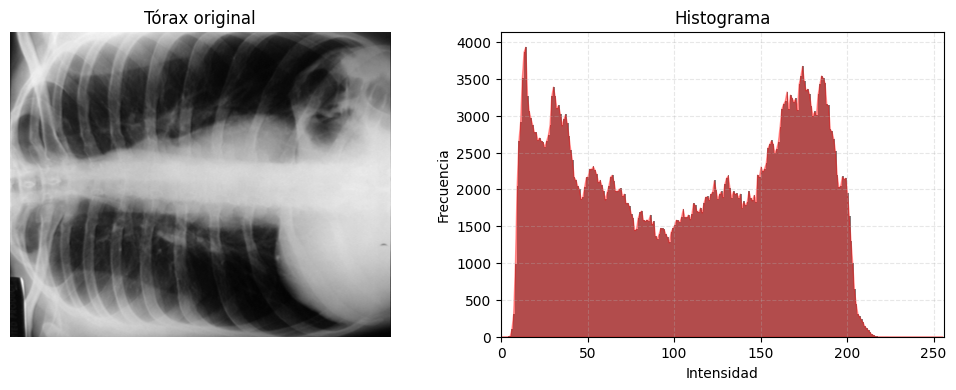

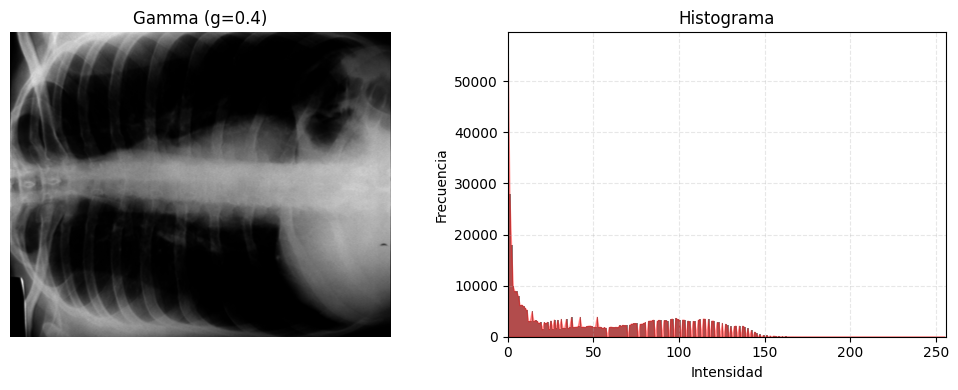

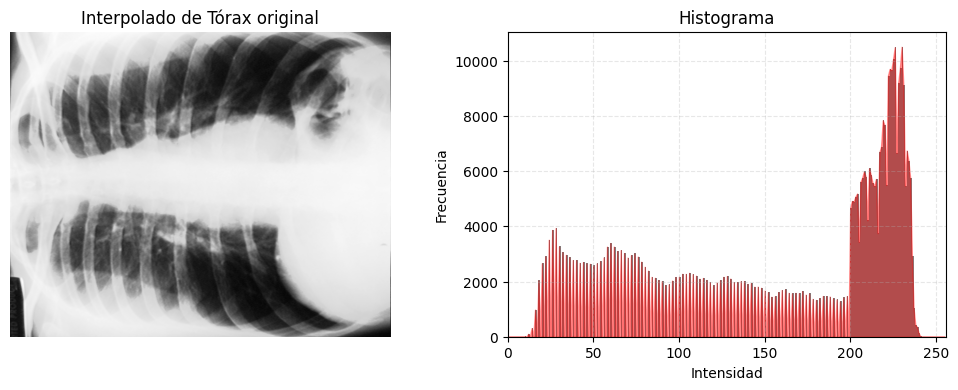

In [95]:
imagen = ProcesadorPDI(cargar_imagen('toraxP.bmp'), titulo="Tórax original")
imagen.show_jupyter()
imagen.gamma_transform(0.4).show_jupyter()
imagen.interpolar([0, 100, 255], [0, 200, 255]).show_jupyter()

b) Una vez que ha regresado el paciente con su radiografía al consultorio, el médico sospecha de
problemas en el pulmón y el hígado al enterarse que el paciente consume alcohol y tabaco en
cantidades no recomendables. ¿Podría usted mejorar la radiografía para facilitar el diagnóstico en este
caso? Explique cómo seleccionó el procesamiento aplicado.

c) Después de discutir sus malos hábitos, el paciente comenta de cierto dolor en la articulación de la
cadera, justo en la parte alta de la pierna derecha. Mejore la imagen de tal forma que sea mas clara esta
articulación. Explique cómo seleccionó el procesamiento aplicado.